# Extração

In [3]:
import pandas as pd
import numpy as np

In [31]:
import pandas as pd
import requests

url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json'


dados = pd.read_json(url)

dados.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [32]:

customer = pd.json_normalize(dados['customer'])
phone = pd.json_normalize(dados['phone'])
internet = pd.json_normalize(dados['internet'])
account = pd.json_normalize(dados['account'])


dados_final = pd.concat([
    dados[['customerID', 'Churn']],
    customer,
    phone,
    internet,
    account
], axis=1)


dados_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# Transformação

In [33]:
print(dados_final.isna().sum())

customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


In [34]:
# dados_final.duplicated().sum()
print(dados_final.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [35]:
dados_final['Charges.Total'] = pd.to_numeric(dados_final['Charges.Total'], errors='coerce')

In [36]:
dados_final['Charges.Total'] = dados_final['Charges.Total'].fillna(0)

In [49]:
dados_final['Contas_Diarias'] = np.where(
    dados_final['tenure'] > 0,
    dados_final['Charges.Total'] / dados_final['tenure'],
    0
)

dados_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias,Gastos_Diarios
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,65.922222,0.24
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,60.266667,0.22
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,70.212500,0.62
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,95.219231,0.25
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,89.133333,0.93


In [38]:
dados_final.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total',
       'Contas_Diarias'],
      dtype='object')

In [39]:
mapeamento = {'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0}


colunas_para_binario = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

dados_final[colunas_para_binario] = dados_final[colunas_para_binario].replace(mapeamento)


dados_final[colunas_para_binario].head()

/tmp/ipykernel_151/3932927494.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dados_final[colunas_para_binario] = dados_final[colunas_para_binario].replace(mapeamento)


,Churn,Partner,Dependents,PhoneService,PaperlessBilling
0,0,1,1,1,1
1,0,0,0,1,0
2,1,0,0,1,1
3,1,1,0,1,1
4,1,1,0,1,1


# Carga e Analise

In [50]:
dados_final.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Contas_Diarias,Gastos_Diarios
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.00
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2279.734304,64.698218,inf
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.794470,30.270670,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000,0.01
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,398.550000,35.649000,0.04
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1394.550000,70.300000,0.07
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,90.174158,0.22
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,121.400000,inf


In [47]:

resumo_numerico = dados_final.describe()
print("Análise Descritiva - Numérica:")
display(resumo_numerico)

Análise Descritiva - Numérica:


,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Contas_Diarias,Gastos_Diarios
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.00
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2279.734304,inf,inf
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.794470,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.268056,0.01
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,398.550000,1.278093,0.04
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1394.550000,2.150000,0.07
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,6.641190,0.22
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,inf,inf


In [43]:

dados_final['Churn'] = dados_final['Churn'].astype(str).replace({
    'Yes': '1',
    'No': '0',
    '1': '1',
    '0': '0',
    'True': '1',
    'False': '0'
})


dados_final['Churn'] = pd.to_numeric(dados_final['Churn'], errors='coerce')

dados_final['tenure'] = pd.to_numeric(dados_final['tenure'], errors='coerce')

dados_final.dropna(subset=['Churn', 'tenure'], inplace=True)

dados_final['Churn'] = dados_final['Churn'].astype(int)
dados_final['tenure'] = dados_final['tenure'].astype(int)

print(f"Taxa de Churn: {dados_final['Churn'].mean() * 100:.2f}%")
print(f"Tempo médio: {dados_final['tenure'].mean():.1f} meses")

Taxa de Churn: 26.54%
Tempo médio: 32.4 meses


/tmp/ipykernel_151/3224489201.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=dados_final, palette='viridis')


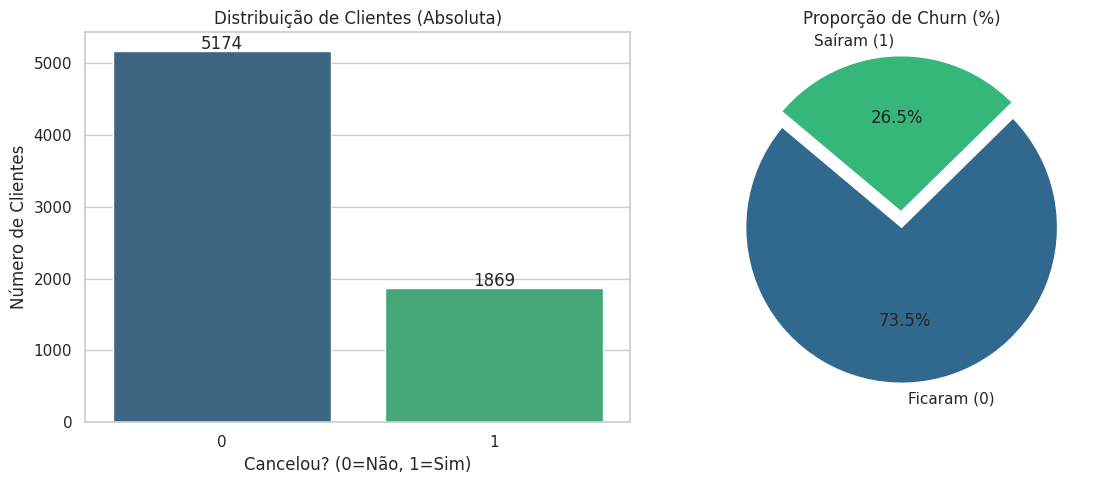

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
ax = sns.countplot(x='Churn', data=dados_final, palette='viridis')
plt.title('Distribuição de Clientes (Absoluta)')
plt.xlabel('Cancelou? (0=Não, 1=Sim)')
plt.ylabel('Número de Clientes')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 5), textcoords = 'offset points')


plt.subplot(1, 2, 2)
churn_counts = dados_final['Churn'].value_counts()
plt.pie(churn_counts, labels=['Ficaram (0)', 'Saíram (1)'], autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('viridis', 2), explode=(0, 0.1))
plt.title('Proporção de Churn (%)')

plt.tight_layout()
plt.show()

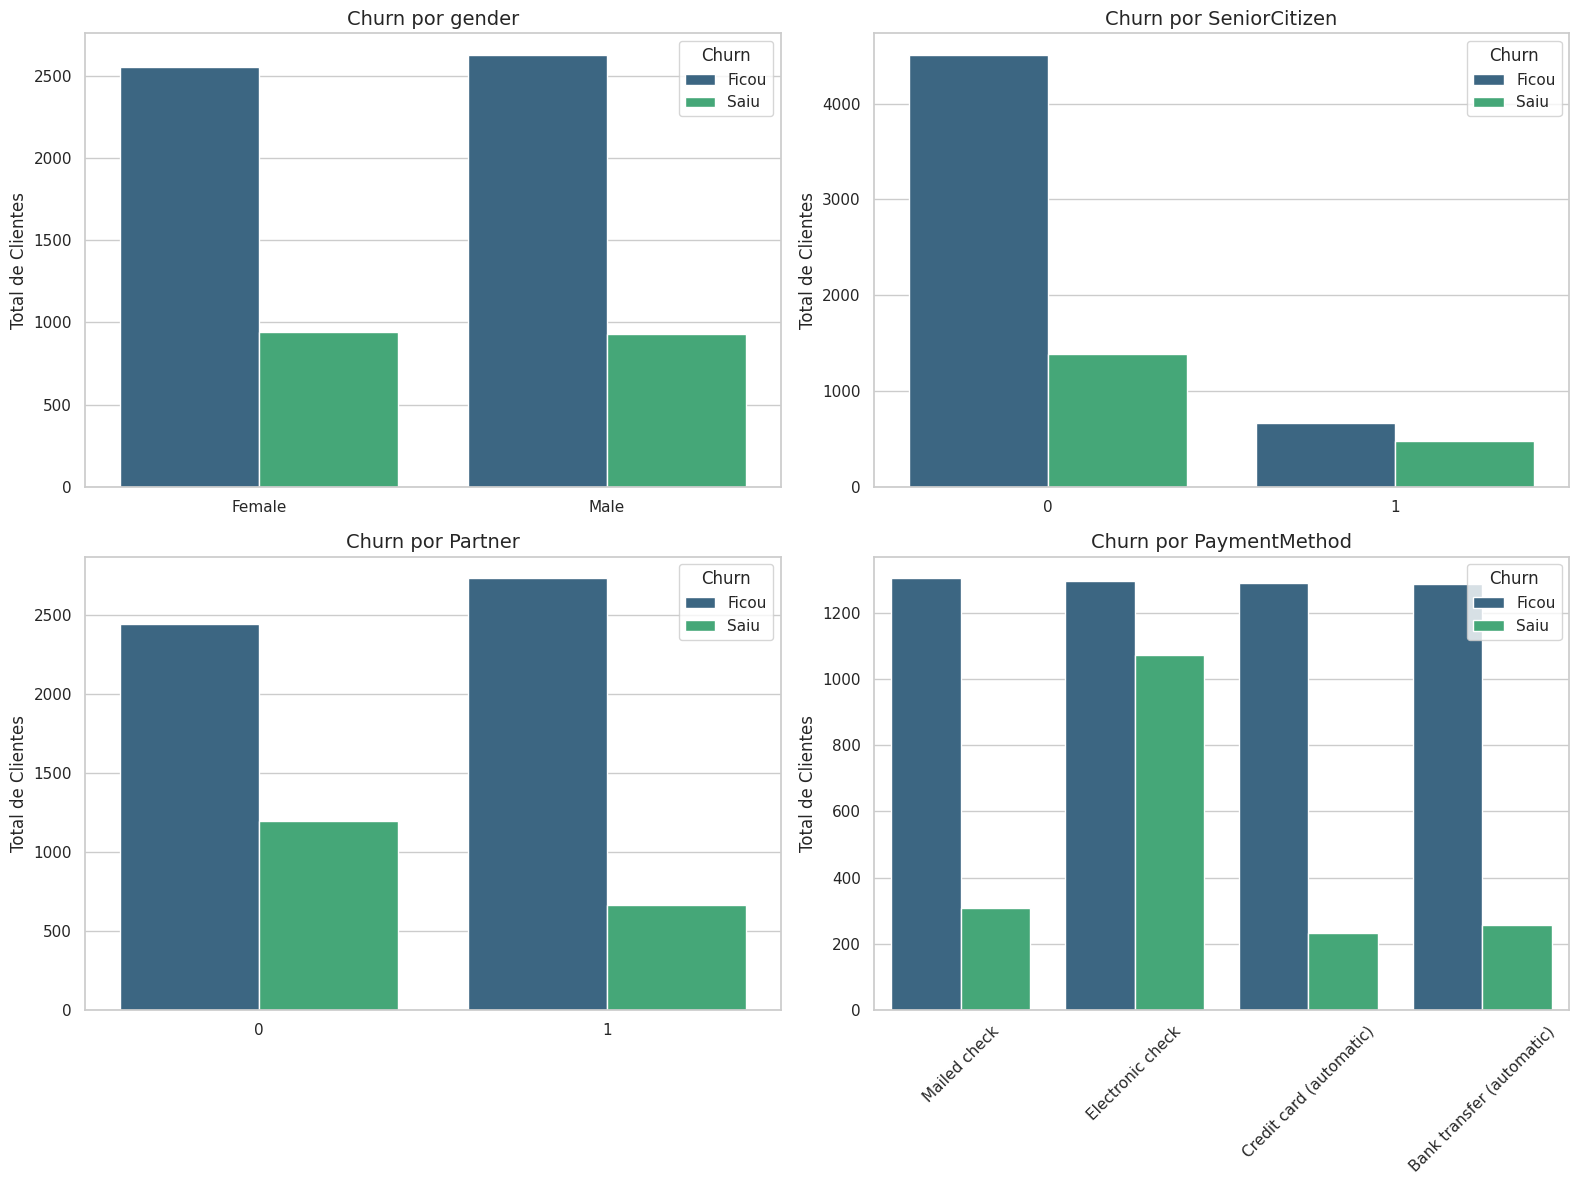

In [54]:

colunas_categoricas = ['gender', 'SeniorCitizen', 'Partner', 'PaymentMethod']


fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas):

    sns.countplot(x=col, hue='Churn', data=dados_final, ax=axes[i], palette='viridis')


    axes[i].set_title(f'Churn por {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Total de Clientes')
    axes[i].legend(title='Churn', labels=['Ficou', 'Saiu'])


    if col == 'PaymentMethod':
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_151/4175557783.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=dados_final, palette='Set2')


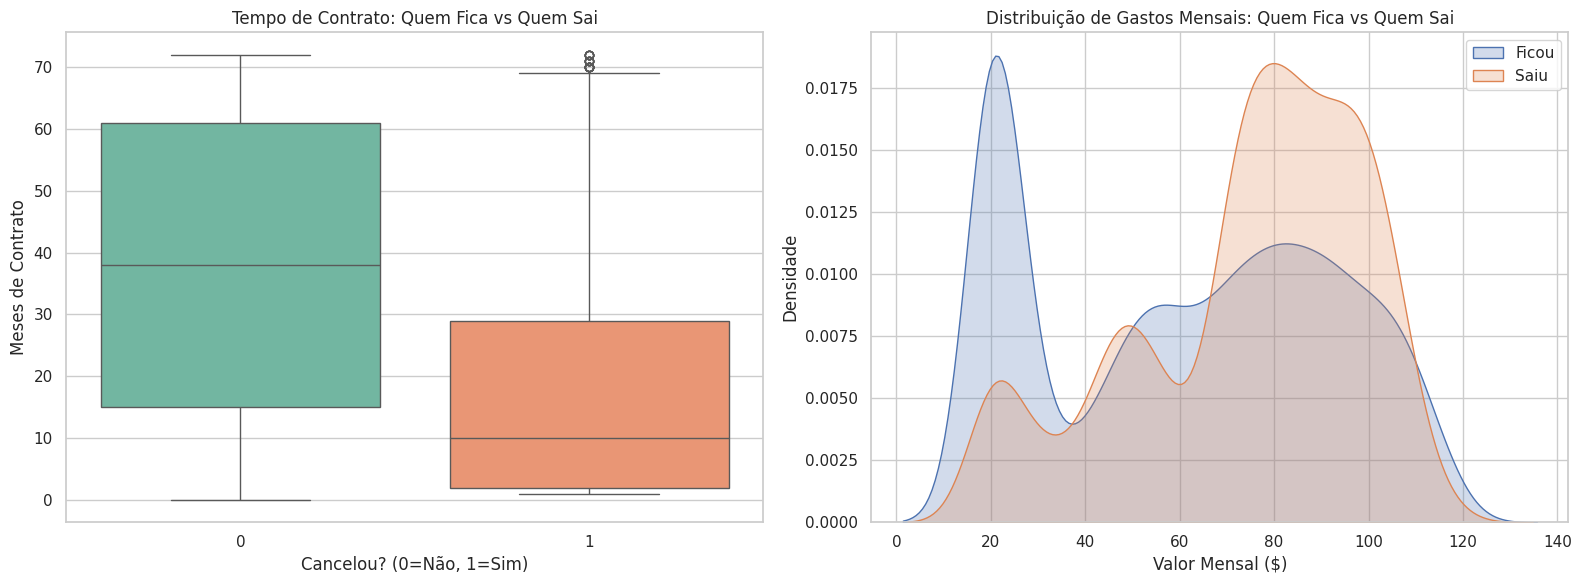

In [57]:

plt.figure(figsize=(16, 6))

# 1. Churn vs Tempo de Contrato (tenure)
plt.subplot(1, 2, 1)
sns.boxplot(x='Churn', y='tenure', data=dados_final, palette='Set2')
plt.title('Tempo de Contrato: Quem Fica vs Quem Sai')
plt.xlabel('Cancelou? (0=Não, 1=Sim)')
plt.ylabel('Meses de Contrato')

# 2. Churn vs Valor Mensal (MonthlyCharges)
plt.subplot(1, 2, 2)
sns.kdeplot(dados_final[dados_final['Churn'] == 0]['Charges.Monthly'], label='Ficou', fill=True)
sns.kdeplot(dados_final[dados_final['Churn'] == 1]['Charges.Monthly'], label='Saiu', fill=True)
plt.title('Distribuição de Gastos Mensais: Quem Fica vs Quem Sai')
plt.xlabel('Valor Mensal ($)')
plt.ylabel('Densidade')
plt.legend()

plt.tight_layout()
plt.show()

# Relatório

### Introdução e Limpeza

Relatório de Análise de Churn - TelecomX

O objetivo desta análise foi investigar o Churn que é a saida de clientes da TelecomX. O Churn é uma das métricas mais críticas para empresas de serviços, pois o custo de adquirir um novo cliente é geralmente muito superior ao de manter um atual.

Limpeza e Tratamento de Dados
Os dados foram extraídos diretamente de uma API em formato JSON. O processo de tratamento incluiu:

Normalização: Expansão de colunas aninhadas (customer, phone, internet, account) para um formato tabular.

Conversão de Tipos: Transformação de colunas como Charges.TOtal e tenure para formatos numéricos.

Tratamento de Dados Ausentes: Identificação de valores vazios em novos clientes, preenchidos estrategicamente com 0.

Codificação: Transformação da variável alvo Churn e outras categóricas em valores binários (0 e 1) para permitir análises matemáticas e o cálculo da taxa de evasão.

Engenharia de Dados: Criação da métrica Custo_Diario

Análise Exploratória de Dados
Durante a análise, identificamos padrões visuais claros através de gráficos:

Distribuição de Churn: A base apresenta uma taxa de evasão de aproximadamente 26.54%

Perfil de Contrato: Clientes com contratos mensais (Month-to-month) possuem uma taxa de cancelamento drasticamente superior aos contratos anuais.

Comportamento de Gastos: Clientes que cancelam tendem a ter gastos mensais mais elevados

Tempo de Casa: O risco de Churn é altíssimo nos primeiros 6 meses de contrato, diminuindo conforme o cliente ganha tempo de casa (tenure).



### COnclusão

Conclusões
O "Período Crítico": A maior parte da evasão ocorre no início da jornada do cliente.

Sensibilidade a Preço: Clientes com pacotes mais caros são mais propensos a sair, sugerindo que o valor percebido pode não estar acompanhando o custo.

Fator Técnico: Clientes de fibra óptica apresentaram padrões de saída que merecem atenção das equipes de suporte.



